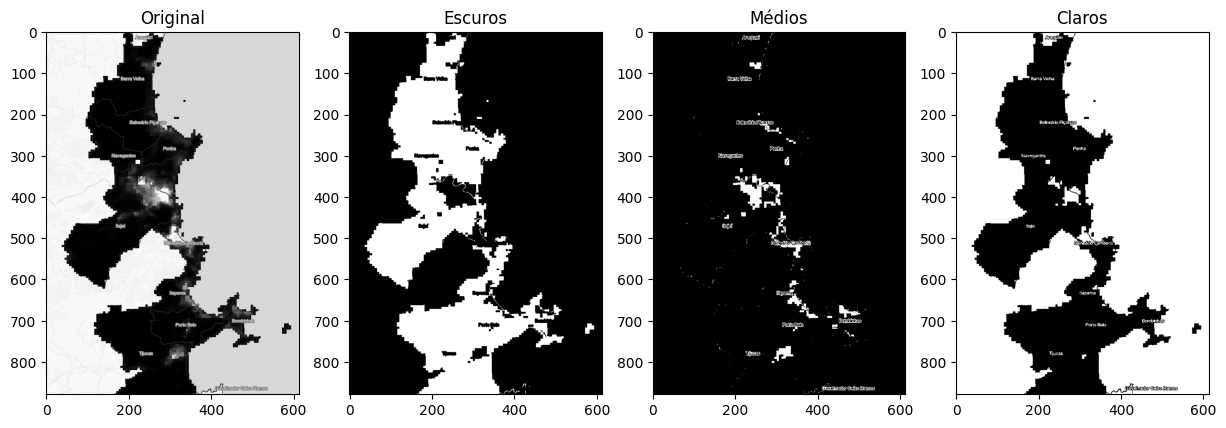

In [ ]:
import matplotlib.pyplot as plt
from skimage import io
import numpy as np
import cv2
from skimage.color import rgb2gray
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import DBSCAN

img = io.imread('Blumenau2015.png')


if img.ndim == 3:
    if img.shape[-1] == 4:
        img = img[:, :, :3]
    img = rgb2gray(img)


img = (img * 255).astype(np.uint8)

camada1 = (img >= 0) & (img < 50)

camada2 = (img >= 50) & (img < 150)

camada3 = (img >= 150) & (img <= 255)

fig, ax = plt.subplots(1,4, figsize=(15,5))

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original')

ax[1].imshow(camada1, cmap='gray')
ax[1].set_title('Escuros')

ax[2].imshow(camada2, cmap='gray')
ax[2].set_title('Médios')

ax[3].imshow(camada3, cmap='gray')
ax[3].set_title('Claros')

plt.show()

In [ ]:
from skimage import io
from skimage.color import rgb2gray
import numpy as np

def carregar_imagem(nome):

    img = io.imread(nome)

    if img.ndim == 3:

        if img.shape[-1] == 4:
            img = img[:, :, :3]

        img = rgb2gray(img)

    img = (img * 255).astype(np.uint8)

    return img

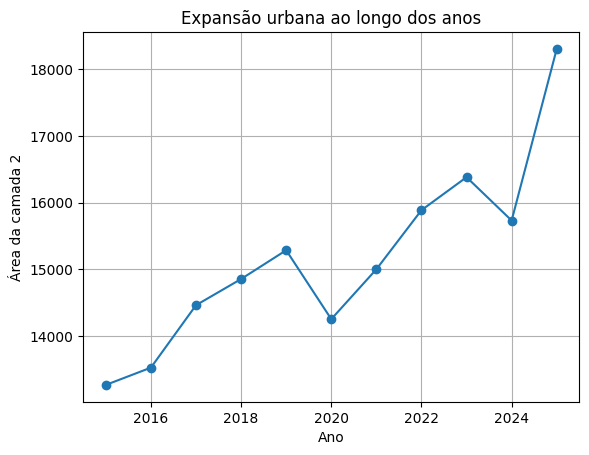

In [ ]:
anos = []
areas = []

for ano in range(2015, 2026):

    img = carregar_imagem(f'Blumenau{ano}.png')

    camada2 = (img >= 50) & (img < 150)

    area = np.sum(camada2)

    anos.append(ano)
    areas.append(area)

plt.plot(anos, areas, marker='o')

plt.xlabel('Ano')
plt.ylabel('Área da camada 2')

plt.title('Expansão urbana ao longo dos anos')

plt.grid()

plt.show()

In [ ]:
anos = []
num_clusters = []

for ano in range(2015, 2026):

    img = carregar_imagem(f'Blumenau{ano}.png')

    camada2 = (img >= 50) & (img < 150)

    coords = np.column_stack(
        np.where(camada2)
    )

    db = DBSCAN(
        eps=5,
        min_samples=20
    )

    labels = db.fit_predict(coords)

    clusters = len(set(labels))

    if -1 in labels:
        clusters -= 1

    anos.append(ano)
    num_clusters.append(clusters)

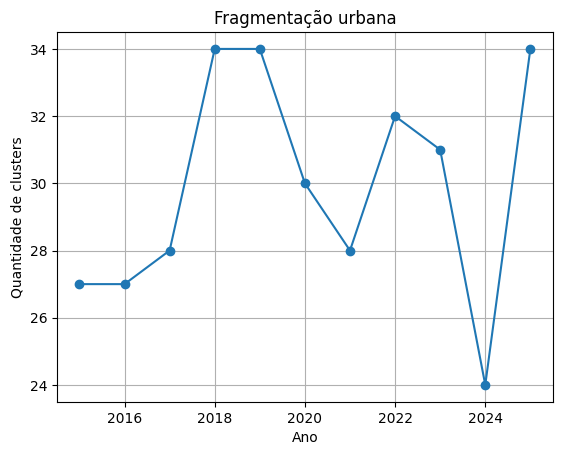

In [ ]:
plt.plot(
    anos,
    num_clusters,
    marker='o'
)

plt.xlabel('Ano')
plt.ylabel('Quantidade de clusters')

plt.title('Fragmentação urbana')

plt.grid()

plt.show()

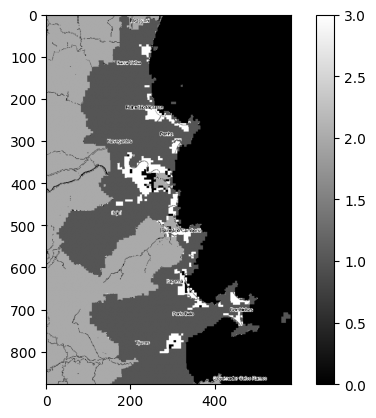

In [ ]:
from sklearn.cluster import KMeans

pixels = img.reshape(-1, 1)

kmeans = KMeans(n_clusters=4)

labels = kmeans.fit_predict(pixels)

segmentada = labels.reshape(img.shape)

plt.imshow(segmentada, cmap='gray')
plt.colorbar()
plt.show()

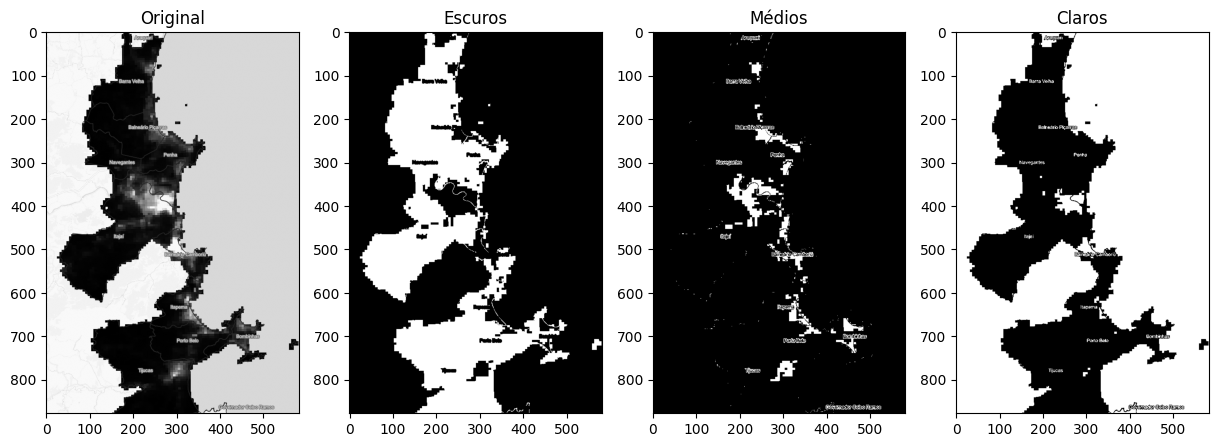

In [ ]:

img2025 = io.imread('Blumenau2025.png')


if img2025.ndim == 3:
    if img2025.shape[-1] == 4:
        img2025 = img2025[:, :, :3]
    img2025 = rgb2gray(img2025)


img2025 = (img2025 * 255).astype(np.uint8)

camada12025 = (img2025 >= 0) & (img2025 < 50)

camada22025 = (img2025 >= 50) & (img2025 < 150)

camada32025 = (img2025 >= 150) & (img2025 <= 255)

fig, ax = plt.subplots(1,4, figsize=(15,5))

ax[0].imshow(img2025, cmap='gray')
ax[0].set_title('Original')

ax[1].imshow(camada12025, cmap='gray')
ax[1].set_title('Escuros')

ax[2].imshow(camada22025, cmap='gray')
ax[2].set_title('Médios')

ax[3].imshow(camada32025, cmap='gray')
ax[3].set_title('Claros')

plt.show()

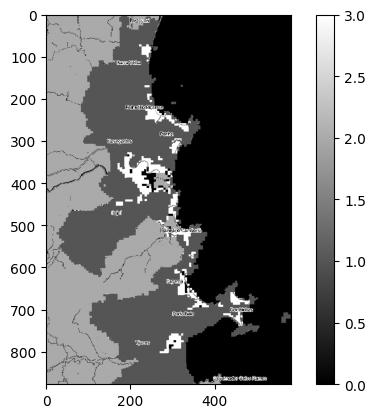

In [ ]:
pixels2025 = img2025.reshape(-1, 1)

kmeans2025 = KMeans(n_clusters=4)

labels2025 = kmeans2025.fit_predict(pixels2025)

segmentada2025 = labels2025.reshape(img2025.shape)

plt.imshow(segmentada2025, cmap='gray')
plt.colorbar()
plt.show()

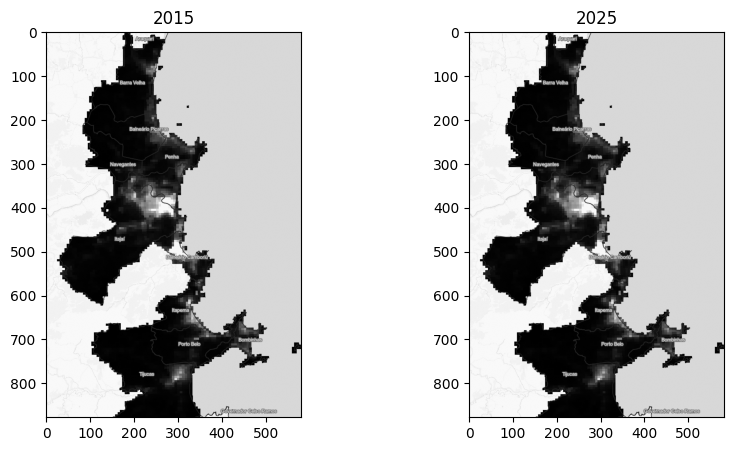

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img, cmap='gray')
ax[0].set_title('2015')

ax[1].imshow(img2025, cmap='gray')
ax[1].set_title('2025')

plt.show()

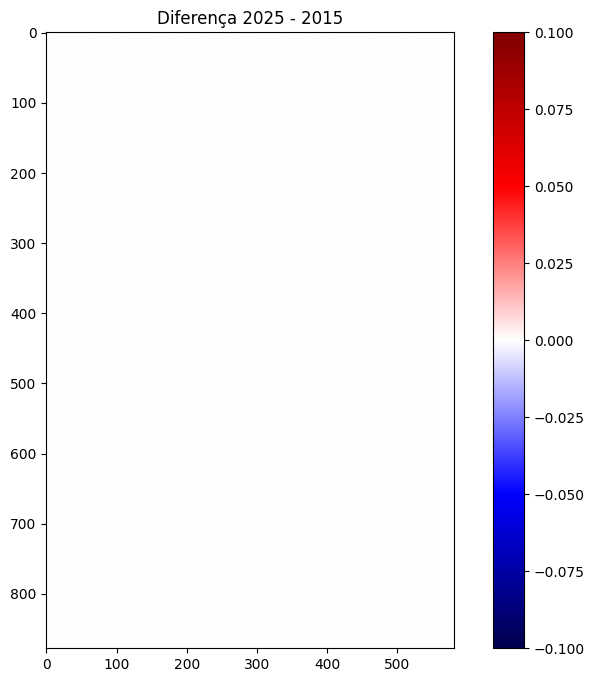

In [ ]:
img2025 = cv2.resize(
    img2025,
    (img.shape[1], img.shape[0])
)
diferenca = img2025.astype(np.int16) - img.astype(np.int16)

plt.figure(figsize=(10,8))
plt.imshow(diferenca, cmap='seismic')
plt.colorbar()
plt.title('Diferença 2025 - 2015')
plt.show()

In [ ]:

coords = np.column_stack(
    np.where(camada22025)
)

db = DBSCAN(
    eps=5,
    min_samples=20
)

labels = db.fit_predict(coords)

valid_labels = labels[labels != -1]

clusters2025 = len(set(labels)) - (1 if -1 in labels else 0)

print("Clusters 2025:", clusters2025)

if 0 in valid_labels and 1 in valid_labels:
    clusterA = coords[labels == 0]
    clusterB = coords[labels == 1]

    if len(clusterA) > 0 and len(clusterB) > 0:
        distancias = euclidean_distances(clusterA, clusterB)
        distancia_minima_2025 = distancias.min()
        print("Distância mínima entres cidades 2025:", distancia_minima_2025)


Clusters 2025: 34
Distância mínima entres cidades 2025: 46.010868281309364


In [ ]:
clusters = []

for label in set(labels):

    if label == -1:
        continue

    pontos = coords[labels == label]

    clusters.append(pontos)


clusters = sorted(
    clusters,
    key=lambda x: len(x),
    reverse=True
)

clusterA = clusters[0]
clusterB = clusters[1]

In [ ]:

coords2015 = np.column_stack(np.where(camada2))
coords2025 = np.column_stack(np.where(camada22025))

db = DBSCAN(
    eps=5,
    min_samples=20
)

labels2015 = db.fit_predict(coords2015)

clusters2015 = len(set(labels2015)) - (1 if -1 in labels2015 else 0)

print("Clusters 2015:", clusters2015)


valid_labels2015 = labels2015[labels2015 != -1]

if 0 in valid_labels2015 and 1 in valid_labels2015:
    clusterA_2015 = coords2015[labels2015 == 0]
    clusterB_2015 = coords2015[labels2015 == 1]

    if len(clusterA_2015) > 0 and len(clusterB_2015) > 0:
        distancias_2015 = euclidean_distances(clusterA_2015, clusterB_2015)
        distancia_minima_2015 = distancias_2015.min()
        print("Distância mínima entre cidades 2015:", distancia_minima_2015)


Clusters 2015: 34
Distância mínima entre cidades 2015: 46.010868281309364


Centroide 2015: [468.85308419 290.21504671]
Centroide 2025: [468.85308419 290.21504671]


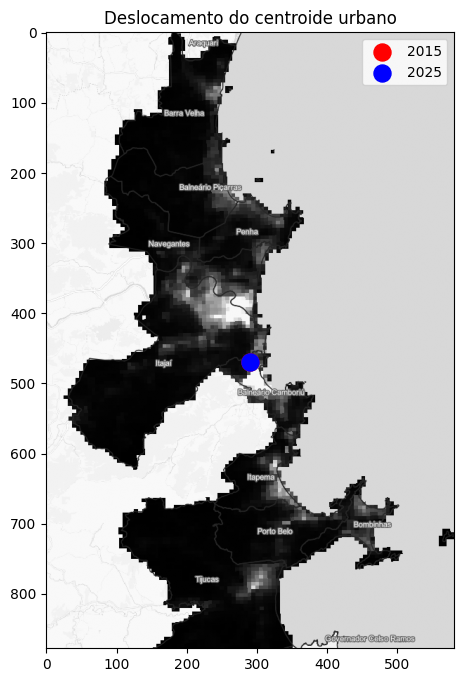

In [ ]:
centroide2015 = coords2015.mean(axis=0)
centroide2025 = coords2025.mean(axis=0)

print("Centroide 2015:", centroide2015)
print("Centroide 2025:", centroide2025)

plt.figure(figsize=(10,8))

plt.imshow(img2025, cmap='gray')

plt.scatter(
    centroide2015[1],
    centroide2015[0],
    c='red',
    s=150,
    label='2015'
)

plt.scatter(
    centroide2025[1],
    centroide2025[0],
    c='blue',
    s=150,
    label='2025'
)

plt.legend()
plt.title("Deslocamento do centroide urbano")
plt.show()

In [ ]:
area_20153 = np.sum(camada3)
area_20253 = np.sum(camada32025)
area_20152 = np.sum(camada2)
area_20252 = np.sum(camada22025)
area_20151 = np.sum(camada1)
area_20251 = np.sum(camada12025)


crescimento1 = ((area_20251 - area_20151) / area_20151) * 100
crescimento2 = ((area_20252 - area_20152) / area_20152) * 100
crescimento3 = ((area_20253 - area_20153) / area_20153) * 100


print("Crescimento urbano primeira camada: ", crescimento1, "%")
print("Crescimento urbano segunda camada:", crescimento2, "%")
print("Crescimento urbano terceira camada: ", crescimento3, "%")

Crescimento urbano primeira camada:  -4.563320326356864 %
Crescimento urbano segunda camada: 0.0 %
Crescimento urbano terceira camada:  -6.87222768235545 %
